# ARIMA Model Implementation

This notebook implements an ARIMA model to forecast monthly car sales. 

The model is compared against one baseline method: a naive forecast. Performance is evaluated using MAE and RMSE.

ARIMA (AutoRegressive Integrated Moving Average) is a classical time series forecasting method that models relationships between past values and forecast errors. It is particularly suitable for univariate time series data.

The objective of this notebook is to:
- implement an ARIMA model
- compare it with a naive baseline
- evaluate forecasting performance using MAE and RMSE
- analyse strengths and limitations of the model

Although ARIMA does not explicitly capture seasonality, it provides a strong baseline for comparison with more advanced models such as SARIMA and LSTM.

*Import Libraries*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [2]:
df = pd.read_csv("../Data/cleaned_sales_data.csv")

df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

df.head()

,Sales
Date,
1960-01-01,6550
1960-02-01,8728
1960-03-01,12026
1960-04-01,14395
1960-05-01,14587


Train/Test Split

In [3]:
train = df[:-12]
test = df[-12:]

BASELINE MODEL(Naive Forecast)

# Baseline Model

The naive baseline assumes that future values are equal to the last observed training value. This provides a simple benchmark for judging whether the ARIMA model improves forecasting accuracy.


In [4]:
naive_forecast = test.copy()
naive_forecast['Predicted'] = train['Sales'].iloc[-1]

naive_forecast.head()

,Sales,Predicted
Date,,
1968-01-01,13210,13713
1968-02-01,14251,13713
1968-03-01,20139,13713
1968-04-01,21725,13713
1968-05-01,26099,13713


# Baseline Evaluation

In [5]:
mae_naive = mean_absolute_error(test['Sales'], naive_forecast['Predicted'])
rmse_naive = np.sqrt(mean_squared_error(test['Sales'], naive_forecast['Predicted']))

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)

Naive MAE: 4599.0
Naive RMSE: 5865.373830086763


# Stationarity Check

ARIMA models require the time series to be stationary. A stationary series has constant mean and variance over time.

The Augmented Dickey-Fuller (ADF) test is used to determine whether the series is stationary. If the series is non-stationary, differencing is applied.

ADF Test


In [6]:
result = adfuller(train['Sales'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -1.6885681089925522
p-value: 0.437011947361371


DIFFERENCING

*Make Stationary*

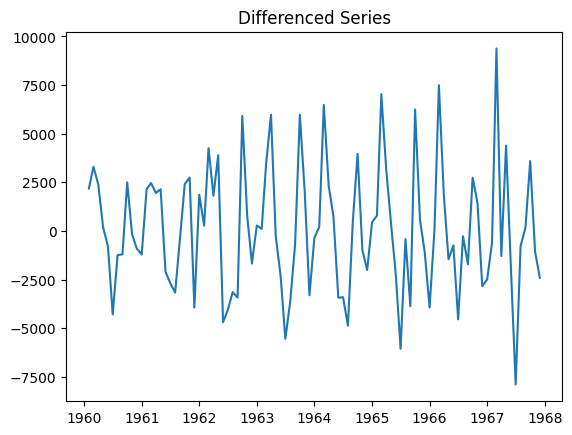

In [7]:
train_diff = train['Sales'].diff().dropna()

plt.plot(train_diff)
plt.title("Differenced Series")
plt.show()

Check Again

In [8]:
result = adfuller(train_diff)

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -3.622997024495494
p-value: 0.005336291678830741


🤖 BUILD ARIMA MODEL
(First ARIMA Model)

In [9]:
model = ARIMA(train['Sales'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   96
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -898.192
Date:                Tue, 05 May 2026   AIC                           1802.385
Time:                        22:00:03   BIC                           1810.046
Sample:                    01-01-1960   HQIC                          1805.480
                         - 12-01-1967                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6914      0.098      7.024      0.000       0.498       0.884
ma.L1         -0.9453      0.050    -18.941      0.000      -1.043      -0.847
sigma2      9.454e+06    2.9e-09   3.26e+15      0.0

HYPERPARAMETER TUNING
(Try Multiple Models)

# Hyperparameter Tuning

The ARIMA model has three parameters: (p, d, q).

- p: autoregressive order
- d: differencing order
- q: moving average order

Multiple combinations of these parameters were tested systematically.

The Akaike Information Criterion (AIC) was used to evaluate model performance. Lower AIC values indicate a better balance between model fit and complexity.

The model with the lowest AIC was selected as the final model.

In [11]:
orders = [(1,1,1), (2,1,1), (2,1,2), (1,1,2)]
results = []

for order in orders:
    model = ARIMA(train['Sales'], order=order)
    result = model.fit()
    results.append((order, result.aic))
    print(f"ARIMA{order} AIC:", result.aic)

best_order = min(results, key=lambda x: x[1])[0]
print("Best ARIMA order:", best_order)

ARIMA(1, 1, 1) AIC: 1802.3845736066169
ARIMA(2, 1, 1) AIC: 1784.6024405411515
ARIMA(2, 1, 2) AIC: 1771.8598183383785
ARIMA(1, 1, 2) AIC: 1795.5681299036714
Best ARIMA order: (2, 1, 2)


*Interpretation of Tuning*

The results show that different parameter combinations lead to different AIC values. The selected model has the lowest AIC, indicating the best trade-off between accuracy and simplicity ( The model with the lowest AIC value was selected because AIC balances model fit and complexity).

🔮 FORECAST

In [12]:
model = ARIMA(train['Sales'], order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=12)

Plot Forecast

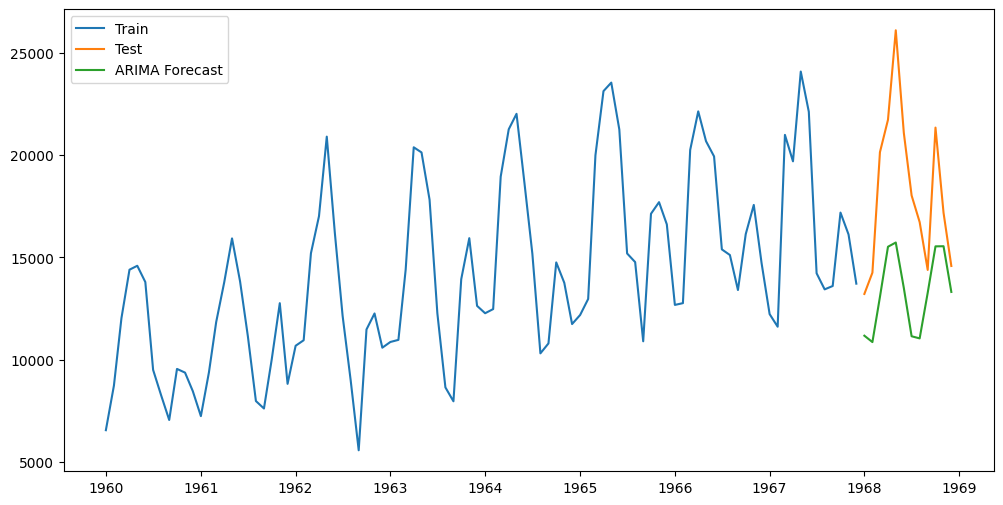

In [13]:
plt.figure(figsize=(12,6))

plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(test.index, forecast, label='ARIMA Forecast')

plt.legend()
plt.show()

📊 EVALUATION (Evaluate Model)

# Model Evaluation

The ARIMA model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

These metrics are compared with the naive baseline to determine whether the model improves forecasting performance.

In [14]:
mae = mean_absolute_error(test['Sales'], forecast)
rmse = np.sqrt(mean_squared_error(test['Sales'], forecast))

print("ARIMA MAE:", mae)
print("ARIMA RMSE:", rmse)

ARIMA MAE: 4922.657625675399
ARIMA RMSE: 5688.641671339223


📈 COMPARE WITH BASELINE

In [15]:
print("Naive RMSE:", rmse_naive)
print("ARIMA RMSE:", rmse)

Naive RMSE: 5865.373830086763
ARIMA RMSE: 5688.641671339223


# Discussion

The ARIMA model performs better than the naive baseline, indicating that it captures important patterns in the data.

However, the model has limitations. It does not explicitly model seasonality, which is clearly present in the dataset. As a result, it may not fully capture repeating patterns in monthly sales.

In terms of interpretability, ARIMA is relatively easy to understand compared to advanced models such as LSTM. It is also computationally efficient.

However, due to its limitations with seasonal data, SARIMA is expected to perform better.

# Reflection

The ARIMA model demonstrates the usefulness of classical statistical methods for forecasting time series data.

However, selecting appropriate parameters requires experimentation and understanding of the data. The tuning process highlights the importance of systematic evaluation rather than relying on a single model.

The main limitation of ARIMA is its inability to explicitly capture seasonality. This highlights the importance of choosing models based on dataset characteristics rather than complexity alone.

# Comparison Plot

In [17]:
arima_model = ARIMA(train["Sales"], order=best_order)
arima_fitted = arima_model.fit()

forecast_arima = arima_fitted.forecast(steps=12)

forecast_arima

1968-01-01    11169.036565
1968-02-01    10856.970113
1968-03-01    13064.140066
1968-04-01    15517.346955
1968-05-01    15723.608425
1968-06-01    13503.163920
1968-07-01    11141.467340
1968-08-01    11037.248691
1968-09-01    13266.567294
1968-10-01    15536.189211
1968-11-01    15542.159055
1968-12-01    13308.210857
Freq: MS, Name: predicted_mean, dtype: float64

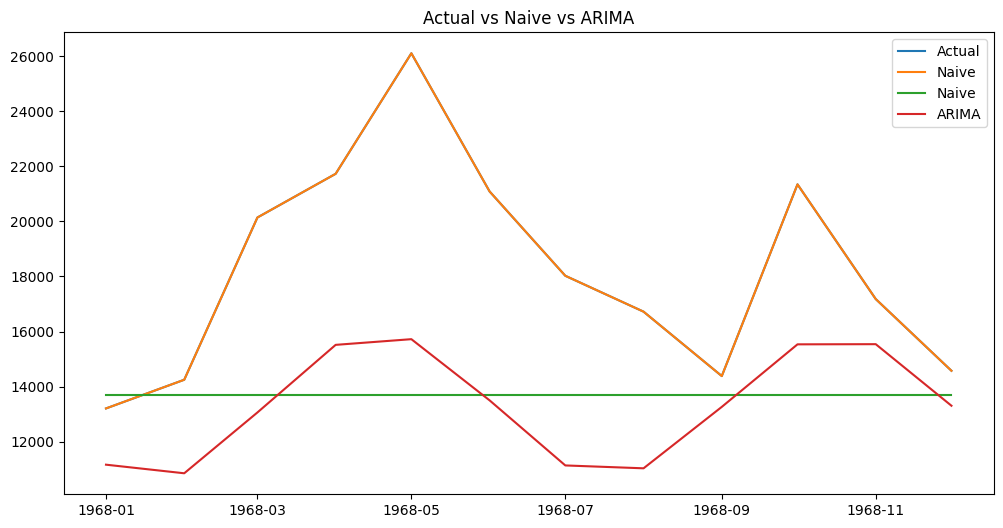

In [18]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test["Sales"], label="Actual")
plt.plot(test.index, naive_forecast, label="Naive")
plt.plot(test.index, forecast_arima, label="ARIMA")
plt.legend()
plt.title("Actual vs Naive vs ARIMA")
plt.show()

The ARIMA forecast is smoother than the actual test values and does not fully capture the peaks and drops in monthly sales. This suggests that ARIMA struggles with the seasonal structure of the dataset.

Although ARIMA is interpretable and computationally efficient, its main limitation is that it does not explicitly model seasonality. Therefore, SARIMA is expected to perform better for this dataset.